Epoch [10/30], Loss: 3.5492, w: 2.5710, b: 1.1697
Epoch [20/30], Loss: 3.5152, w: 2.5622, b: 1.2271
Epoch [30/30], Loss: 3.4848, w: 2.5539, b: 1.2814

真实参数: w = 2.5000, b = 1.8000
学习到的参数: w = 2.5539, b = 1.2814


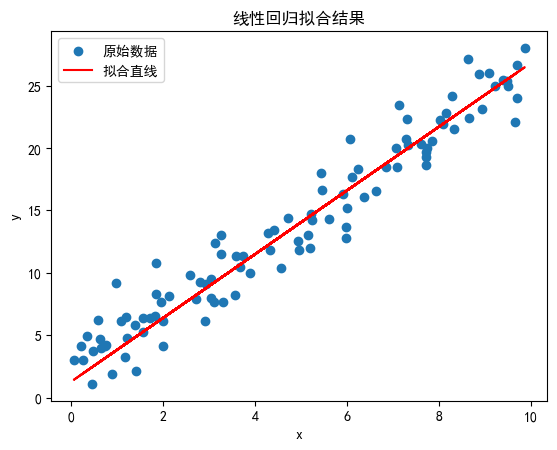

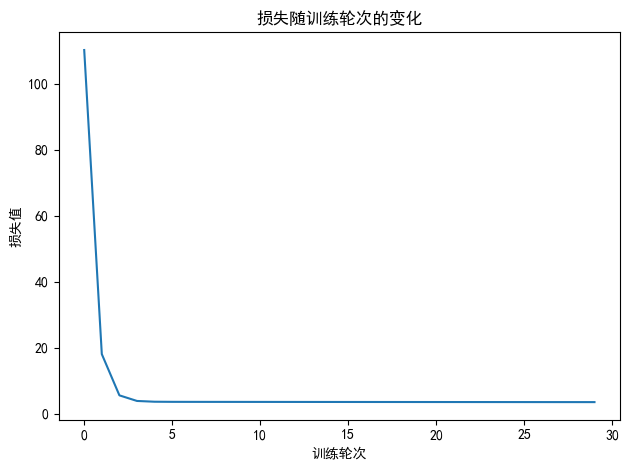

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchviz import make_dot

# 设置中文字体和负号显示
plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

# 1. 生成模拟数据
true_w = 2.5
true_b = 1.8
x = torch.tensor(np.random.rand(100, 1) * 10, dtype=torch.float32)
y = true_w * x + true_b + torch.tensor(np.random.randn(100, 1) * 2, dtype=torch.float32)

# 2. 定义模型
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    
    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

# 3. 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# 4. 生成横向计算图
y_pred = model(x)
loss = criterion(y_pred, y)

# 生成计算图对象
dot = make_dot(loss, params=dict(model.named_parameters()))

# 设置横向布局（关键：添加这一行）
dot.attr(rankdir="LR")  # LR 表示 Left to Right（从左到右）

# 保存并显示
dot.format = 'pdf'
dot.directory = './'
dot.view(filename='linear_regression_graph_LR')  # 文件名含 LR 区分横向图

# 5. 训练模型（省略，同之前代码）
epochs = 30
losses = []
for epoch in range(epochs):
    y_pred = model(x)
    loss = criterion(y_pred, y)
    losses.append(loss.item())
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        w, b = model.parameters()
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, w: {w.item():.4f}, b: {b.item():.4f}')

# 后续参数输出和可视化（同之前代码）
print("\n真实参数: w = {:.4f}, b = {:.4f}".format(true_w, true_b))
w_final, b_final = model.parameters()
print("学习到的参数: w = {:.4f}, b = {:.4f}".format(w_final.item(), b_final.item()))

y_pred = model(x).detach().numpy()
plt.scatter(x.numpy(), y.numpy(), label='原始数据')
plt.plot(x.numpy(), y_pred, 'r-', label='拟合直线')
plt.xlabel('x')
plt.ylabel('y')
plt.title('线性回归拟合结果')
plt.legend()
plt.show()

plt.plot(range(epochs), losses)
plt.xlabel('训练轮次')
plt.ylabel('损失值')
plt.title('损失随训练轮次的变化')
plt.tight_layout()
plt.show()